# Introduction

In this notebook, we perform an analysis of the external DLLs and functions found within our dataset of malicious and benign windows executables. We consider the pairwise similarity of these binaries, visualise our dataset, and explore the characteristics of both executable class in order to guide out later experiments. 

In [64]:
import utils
from os import PathLike
from collections import Counter
from typing import List
import pefile
import numpy as np
from tqdm import tqdm
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
import pandas as pd

mpl.rcParams["figure.dpi"] = 300

PERFORM_EXTRACTION = False
SHUFFLE = True
N = 10

In [65]:
def find_most_similar(similarity_matrix: np.ndarray, n: int = N):
    m, p = similarity_matrix.shape

    assert m == p, "Similarity matrix should be square"

    upper_triangle_indices = np.triu_indices(m, k=1)
    upper_triangle_values = similarity_matrix[upper_triangle_indices]
    top_n_indices = np.argpartition(upper_triangle_values, -n)[-n:]
    top_n_sorted_indices = top_n_indices[
        np.argsort(upper_triangle_values[top_n_indices])[::-1]
    ]
    return np.array(
        [
            (upper_triangle_indices[0][i], upper_triangle_indices[1][i])
            for i in top_n_sorted_indices
        ]
    )


def get_imports(executable_path: PathLike) -> List[str]:
    try:
        pe = pefile.PE(executable_path, fast_load=True)
        pe.parse_data_directories()
        pe.DIRECTORY_ENTRY_IMPORT
        return [
            symb.name.decode("ascii")
            for entry in pe.DIRECTORY_ENTRY_IMPORT
            for symb in entry.imports
            if symb.name is not None
        ]
    except:
        return []


def get_dlls(executable_path: PathLike) -> List[str]:
    try:
        pe = pefile.PE(executable_path)
        pe.DIRECTORY_ENTRY_IMPORT
        return [entry.dll.decode("ascii") for entry in pe.DIRECTORY_ENTRY_IMPORT]
    except:
        return []


dataset = utils.data.MalwareDataset()
labels = np.array([label for _, label in dataset])
programs = np.array([path.split("/")[-1] for path, _ in dataset])

n_mal = np.count_nonzero(labels)
n_ben = len(dataset) - n_mal

# Function Analysis

We begin by analysing external functions used by each of the executables, extracted using the `pefile` python module. External functions which are only seen once across our dataset are removed for performance reasons.

## Feature Extraction

In [66]:
if PERFORM_EXTRACTION:
    imports = {
        "malicious": {},
        "benign": {},
    }
    for path, label in tqdm(dataset, total=len(dataset)):
        exec_imports = get_imports(path)
        imports["malicious" if label == 1 else "benign"][
            path.split("/")[-1]
        ] = exec_imports
    json.dump(imports, open("dataset-imports.json", "w"))
else:
    imports = json.loads(open("dataset-imports.json", "r").read())

In [67]:
fn_usage = Counter(
    [fn for cat in imports for dll in imports[cat].values() for fn in dll]
)

In [68]:
fn_usage_np = np.array(list(fn_usage.values()))
only_seek_once = set(np.array(list(fn_usage.keys()))[fn_usage_np == 1])
print(
    f"{100 * (len(only_seek_once) / len(fn_usage)):.2f}% of functions are only seen once"
)

54.03% of functions are only seen once

In [69]:
common_fns = {k: v for k, v in fn_usage.items() if v > 1}
fn_matrix = np.zeros((len(dataset), len(common_fns)))
fns_used = list(common_fns.keys())

M, N = fn_matrix.shape
loop = tqdm(total=M * N, desc="Generating Matrix", leave=False)

for i, (path, label) in enumerate(dataset):
    if label == 1:
        fns = imports["malicious"][path.split("/")[-1]]
    else:
        fns = imports["benign"][path.split("/")[-1]]

    for j, fn in enumerate(fns_used):
        loop.update(1)
        if fn in fns:
            fn_matrix[i, j] = 1

In [70]:
fn_matrix_processed = fn_matrix.copy()

if SHUFFLE:
    np.random.shuffle(fn_matrix_processed[:n_mal])
    np.random.shuffle(fn_matrix_processed[n_mal:])

## Similarity 

In [71]:
fn_sim = cosine_similarity(fn_matrix_processed)

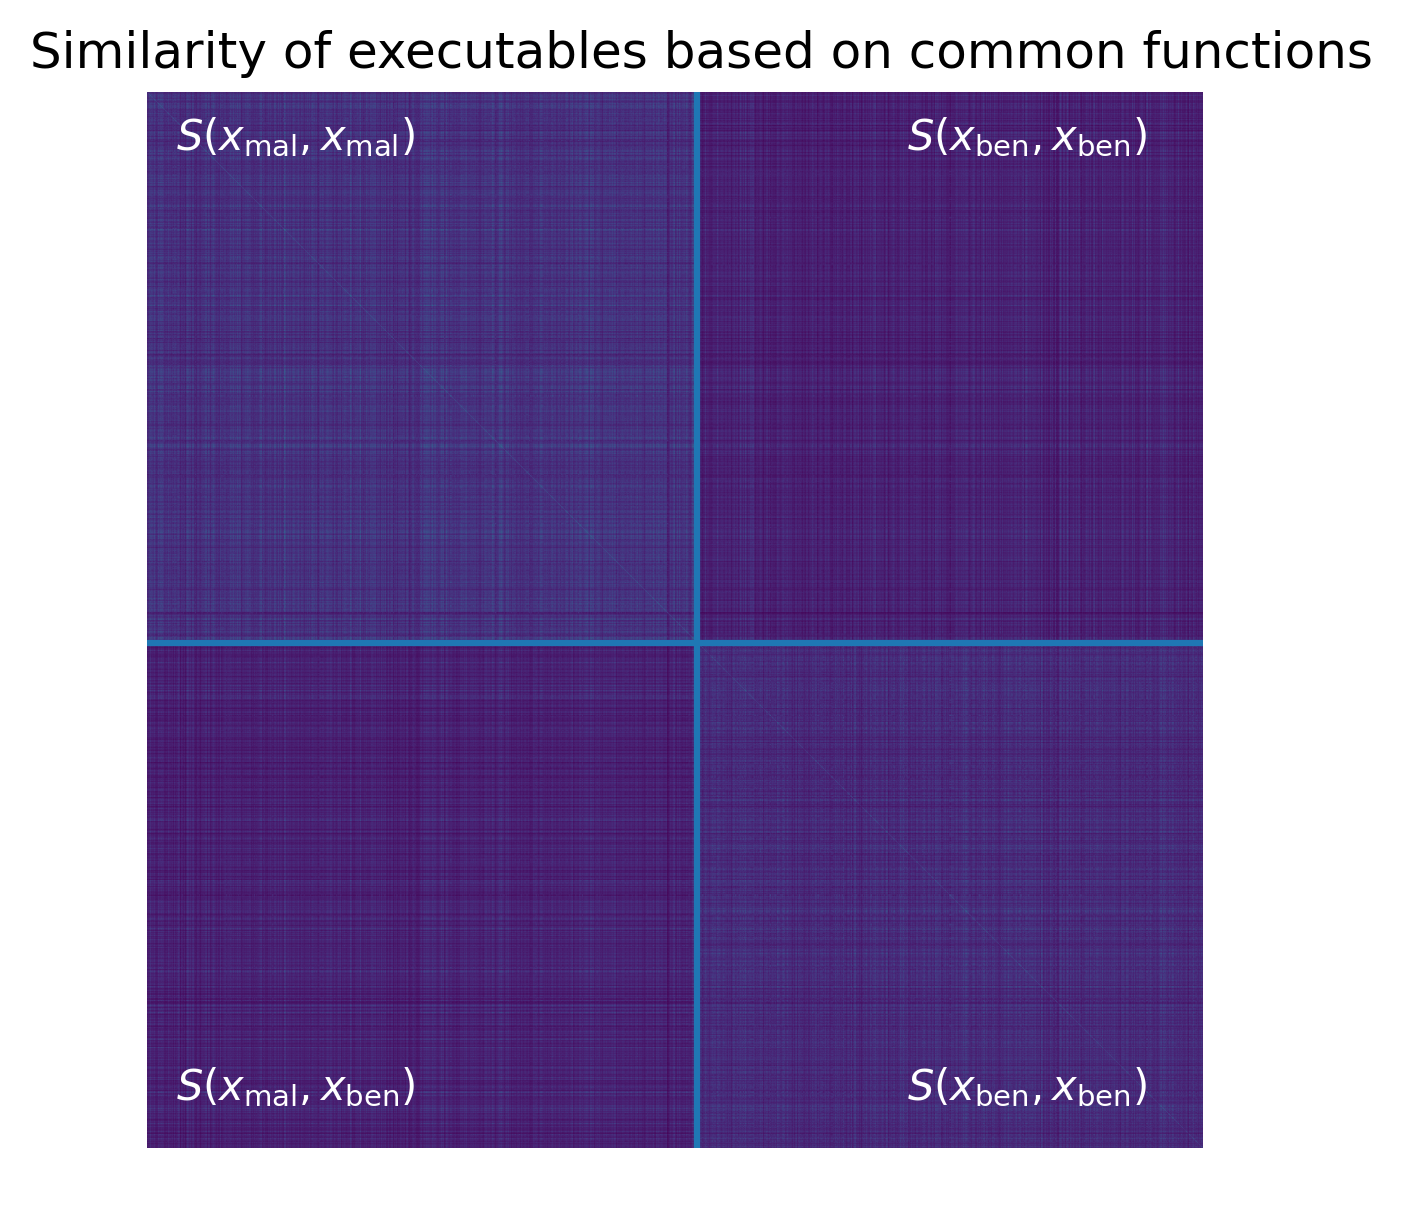

In [72]:
plt.imshow(fn_sim)
plt.axis("off")
plt.title("Similarity of executables based on common functions")
plt.hlines(np.count_nonzero(labels), 0, len(dataset))
plt.vlines(np.count_nonzero(labels), 0, len(dataset))
plt.text(300, 600, r"$S(x_\text{mal}, x_\text{mal})$", c="white")
plt.text(300, 10600, r"$S(x_\text{mal}, x_\text{ben})$", c="white")
plt.text(8000, 10600, r"$S(x_\text{ben}, x_\text{ben})$", c="white")
plt.text(8000, 600, r"$S(x_\text{ben}, x_\text{ben})$", c="white")
plt.show()

In [73]:
most_similar = find_most_similar(fn_sim)
sim = fn_sim[most_similar[:, 0], most_similar[:, 1]]

df = pd.DataFrame(
    {
        ("Similarity", ""): sim,
        ("Programs", "1"): programs[most_similar][:, 0],
        ("Programs", "2"): programs[most_similar][:, 1],
    }
)
df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Similarity                                     Programs  \
                                                        1   
0        1.0  VirusShare_55e6d804f8cbc2ab96321213e686ee0c   
1        1.0  VirusShare_2f0292da91a546e6ea346a30424ffad0   
2        1.0  VirusShare_5bbd71e576d8af11709d5f567a5f2621   
3        1.0                                  rustfmt.exe   
4        1.0      build_script_build-b5656b1583a6566a.exe   
5        1.0  VirusShare_2ee9b227e7a1d311323317411ba683ac   
6        1.0  VirusShare_070796fd31c9a42f8a1531902bb72120   
7        1.0  VirusShare_2ee9b227e7a1d311323317411ba683ac   
8        1.0  VirusShare_3cab4fe6ffd77a0e79981d0a07a92524   
9        1.0  VirusShare_397fcc6f49b60eda60340392bffc48f0   

                                                
                                             2  
0  VirusShare_5768f4331f46feae649736d6d906be80  
1  VirusShare_5fba08f9c8b88c30672682d980eef850  
2  VirusShare_499813ac6e85bae9a26dbd66838269c0  
3                                      cut.exe  
4                               idn-lookup.exe  
5  VirusShare_4a58a7843329650eeb34b14f0a993f90  
6  VirusShare_1ad1ba0277a76d7d0425f080390793f6  
7  VirusShare_3cab4fe6ffd77a0e79981d0a07a92524  
8  VirusShare_4a58a7843329650eeb34b14f0a993f90  
9  VirusShare_4c3a94277a9107156497e282a3f53970

In [74]:
print(f"Average similarity of malicious samples: {np.mean(fn_sim[:n_mal, :n_mal]):.4f}")
print(
    f"Average similarity of malicious and benign samples: {np.mean(fn_sim[n_mal:, :n_mal]):.4f}"
)
print(f"Average similarity of benign samples: {np.mean(fn_sim[n_mal:, n_mal:]):.4f}")

Average similarity of malicious samples: 0.1428

Average similarity of malicious and benign samples: 0.0931

Average similarity of benign samples: 0.1217

## Visualisation 

### PCA 

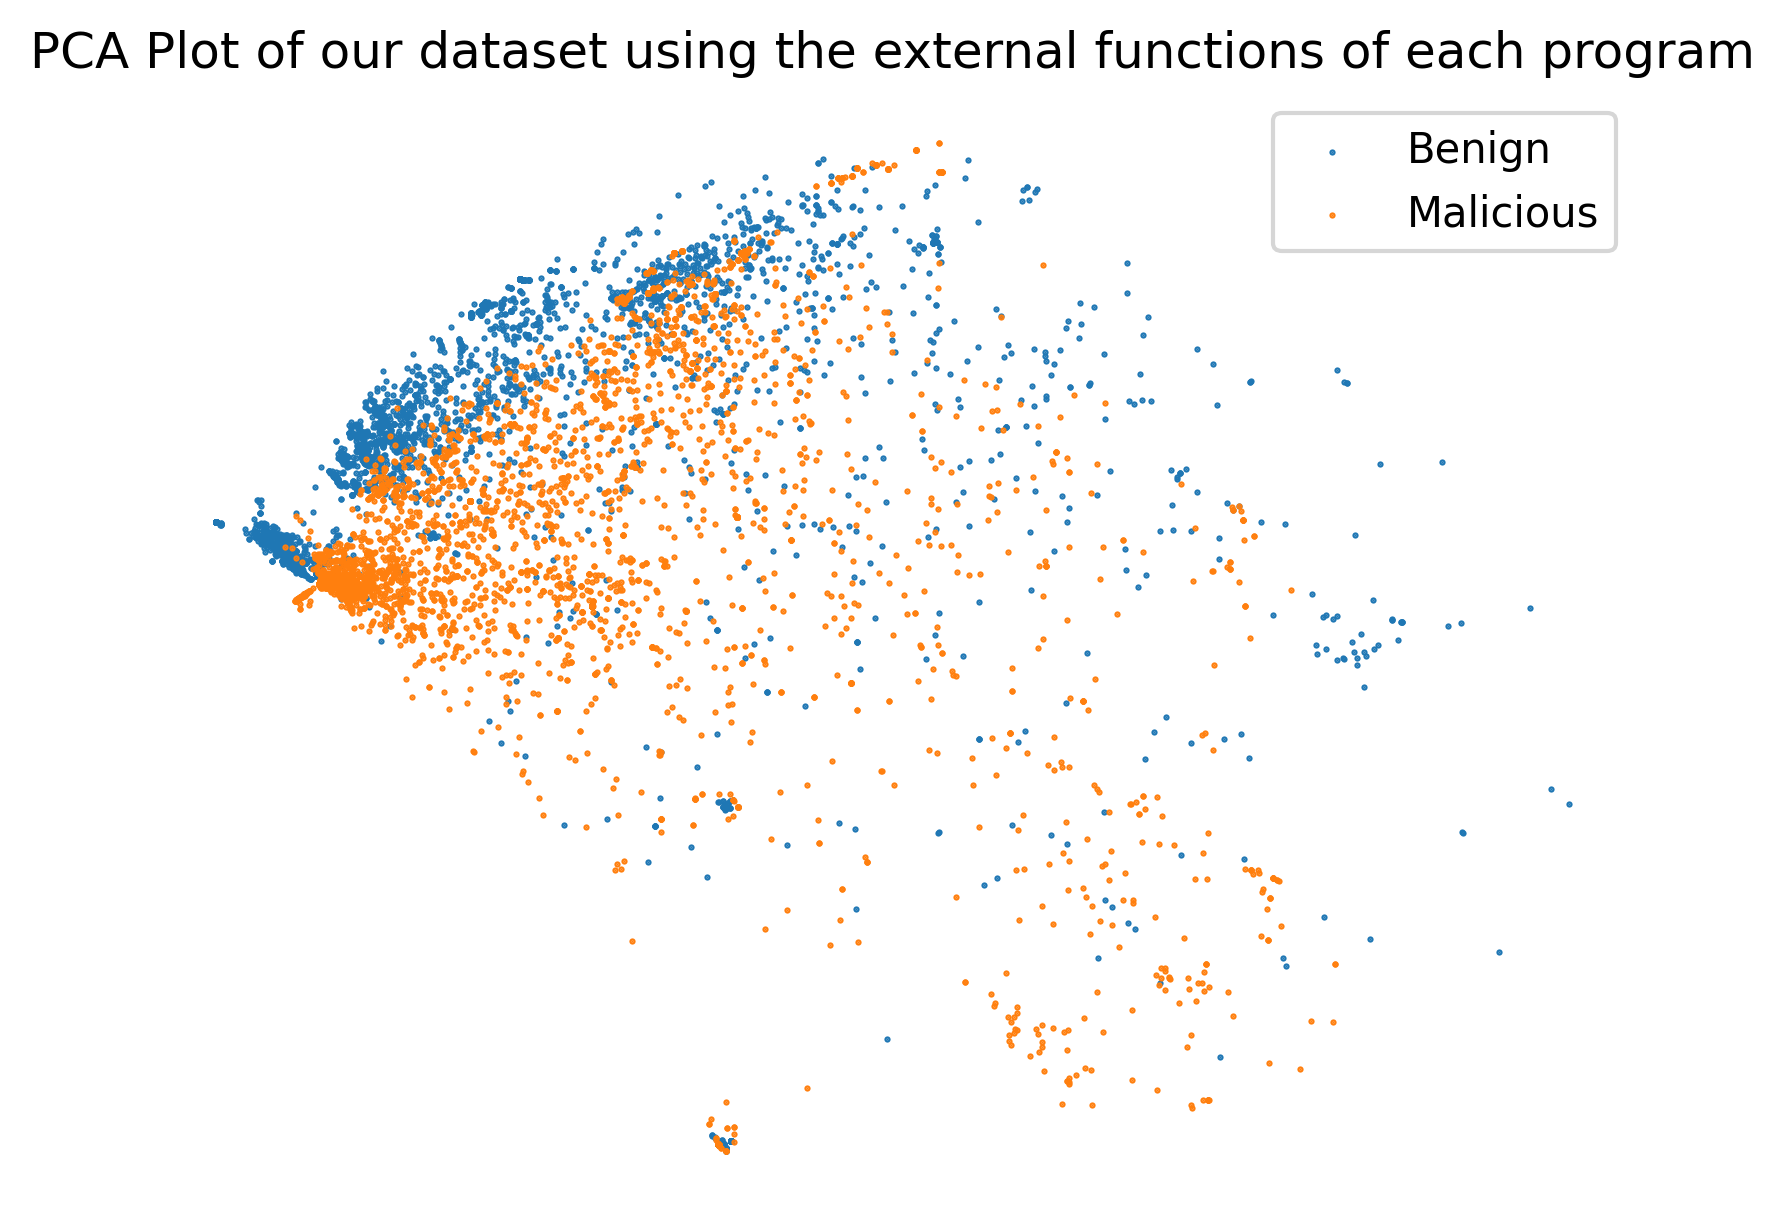

In [75]:
pca = PCA(n_components=2)
X_hat = pca.fit_transform(fn_matrix_processed)

plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("PCA Plot of External Function Features ")
plt.legend()
plt.show()

### MDS

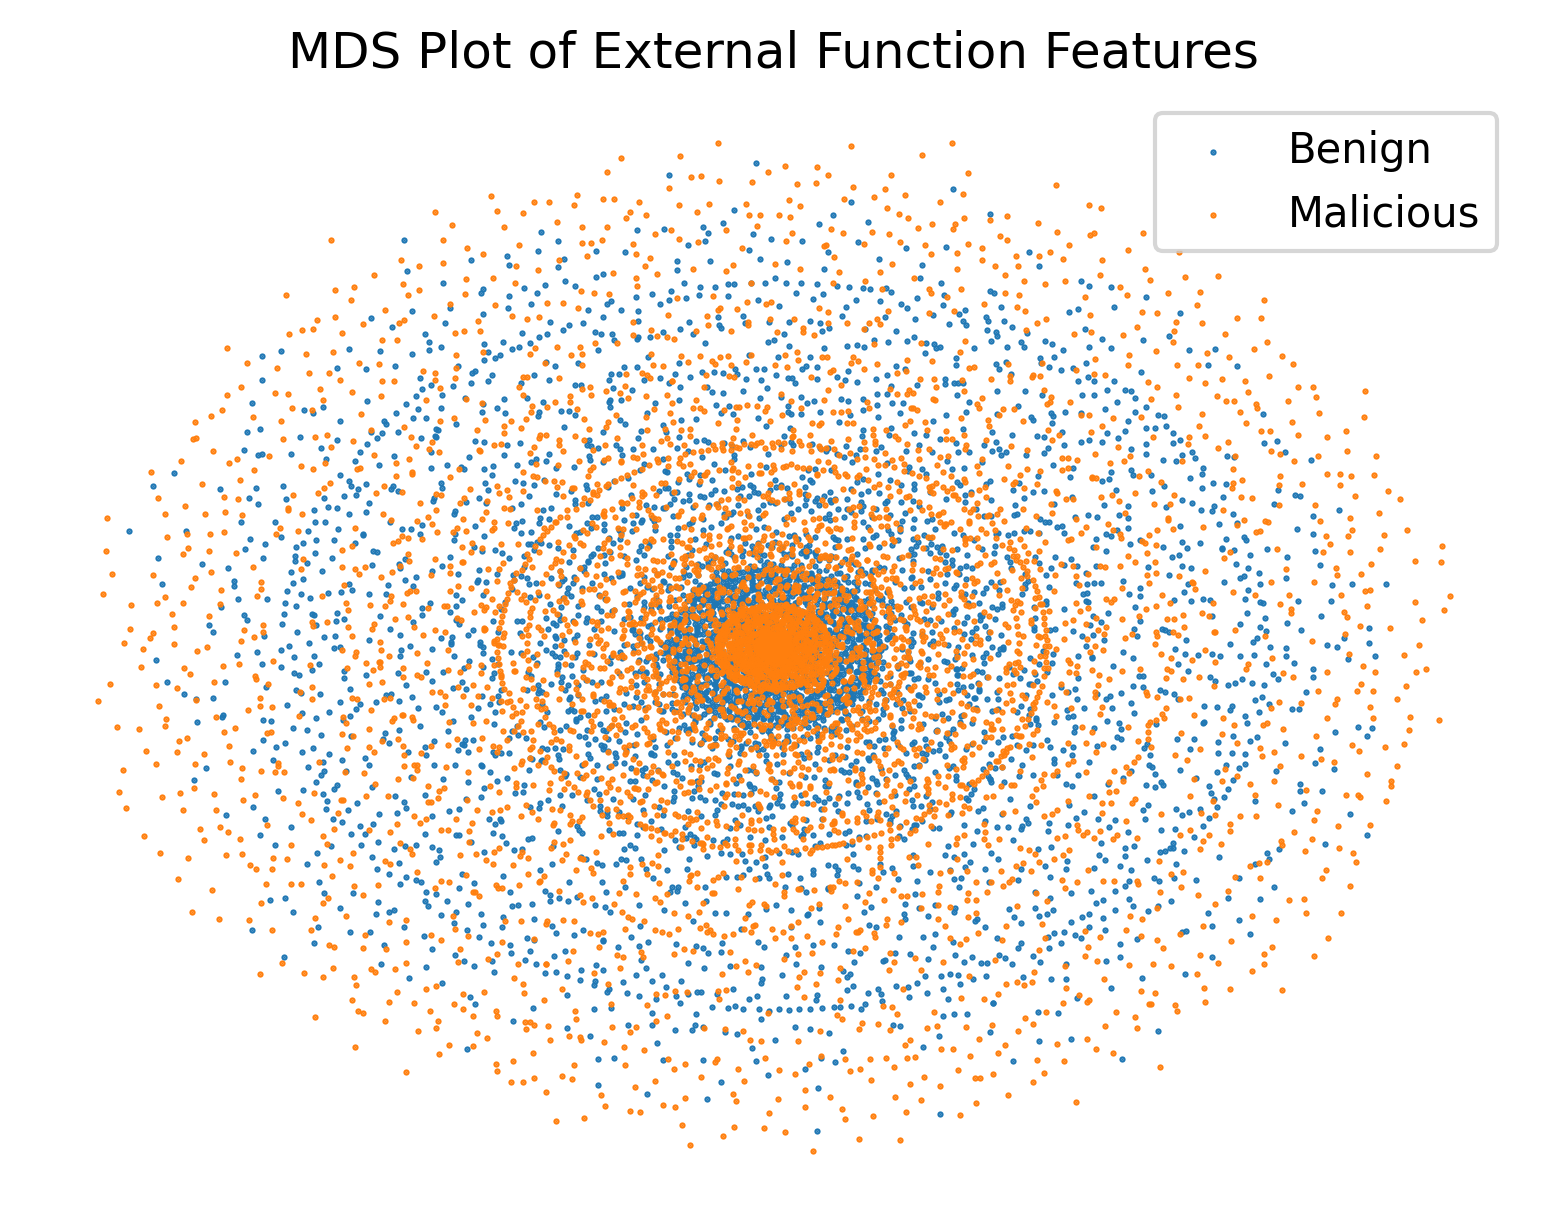

In [ ]:
mds = MDS(dissimilarity="precomputed")
X_hat = mds.fit_transform(fn_sim)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("MDS Plot of External Function Features")
plt.legend()
plt.show()

## Characteristics

In [77]:
malicious_fns = [
    fn
    for program in imports["malicious"].keys()
    for fn in imports["malicious"][program]
]
malicious_fns_usage = Counter(malicious_fns)

benign_fns = [
    fn for program in imports["benign"].keys() for fn in imports["benign"][program]
]
benign_fns_usage = Counter(benign_fns)

### Malicious Functions

External functions which are only seen within malicious executables.  

In [78]:
only_mal = set(malicious_fns) - set(benign_fns)
print(f"{len(only_mal)} Functions only used in malicious binaries")
malicious_usage = {fn: malicious_fns_usage[fn] for fn in only_mal}
malicious_usage = dict(
    reversed(sorted(malicious_usage.items(), key=lambda item: item[1]))
)

pd.DataFrame(
    {
        "Function name": malicious_usage.keys(),
        "Number of occurrences": malicious_usage.values(),
        "Frequency": np.array(list(malicious_usage.values())) / n_mal,
    }
).head(n=10)

11701 Functions only used in malicious binaries

,Function name,Number of occurrences,Frequency
0,__vbaExceptHandler,423,0.073032
1,EVENT_SINK_QueryInterface,391,0.067507
2,EVENT_SINK_Release,391,0.067507
3,EVENT_SINK_AddRef,390,0.067334
4,DllFunctionCall,387,0.066816
5,CorBindToRuntimeEx,244,0.042127
6,_allmul,214,0.036948
7,_adj_fdivr_m16i,209,0.036084
8,_adj_fdiv_m16i,209,0.036084
9,_adj_fprem1,208,0.035912


### Benign Functions

External functions which are only seen in benign executables. 

In [79]:
only_ben = set(benign_fns) - set(malicious_fns)
print(f"{len(only_ben)} Functions only used in benign binaries")
benign_usage = {fn: benign_fns_usage[fn] for fn in only_ben}
benign_usage = dict(reversed(sorted(benign_usage.items(), key=lambda item: item[1])))

pd.DataFrame(
    {
        "Function name": benign_usage.keys(),
        "Number of occurrences": benign_usage.values(),
        "Frequency": np.array(list(benign_usage.values())) / n_ben,
    }
).head(10)

58457 Functions only used in benign binaries

,Function name,Number of occurrences,Frequency
0,__C_specific_handler,1260,0.236709
1,RtlVirtualUnwind,1253,0.235394
2,RtlLookupFunctionEntry,1253,0.235394
3,_register_thread_local_exe_atexit_callback,756,0.142025
4,_crt_atexit,717,0.134698
5,_set_new_mode,716,0.134511
6,_set_app_type,716,0.134511
7,_register_onexit_function,714,0.134135
8,_initialize_onexit_table,714,0.134135
9,_seh_filter_exe,713,0.133947


### Overall

Functions seen in both classes of executable. 

In [80]:
both = set(benign_fns) & set(malicious_fns)
print(f"{len(both)} Functions seen in both classes across dataset")
sorted_usage = dict(
    {
        k: v
        for k, v in reversed(sorted(fn_usage.items(), key=lambda item: item[1]))
        if k in both
    }
)
mfns = [mal_fn for mal_fn in malicious_fns if mal_fn in both]
bfns = [ben_fn for ben_fn in benign_fns if ben_fn in both]

mfns_usage = {k: v for k, v in malicious_fns_usage.items() if k in mfns}
bfns_usage = {k: v for k, v in benign_fns_usage.items() if k in bfns}

mfns_usage = dict(
    reversed(sorted(mfns_usage.items(), key=lambda item: sorted_usage[item[0]]))
)
bfns_usage = dict(
    reversed(sorted(bfns_usage.items(), key=lambda item: sorted_usage[item[0]]))
)

5926 Functions seen in both classes across dataset

In [81]:
df = pd.DataFrame(
    {
        ("Function name", ""): sorted_usage.keys(),
        ("Occurances", "Total"): sorted_usage.values(),
        ("Occurances", "Malicious"): mfns_usage.values(),
        ("Occurances", "Benign"): bfns_usage.values(),
        ("Frequency", "Overall"): np.array(list(sorted_usage.values())) / len(dataset),
        ("Frequency", "Malicious"): np.array(list(mfns_usage.values())) / n_mal,
        ("Frequency", "Benign"): np.array(list(bfns_usage.values())) / n_ben,
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
df.head(10)

Function name Occurances                  Frequency  \
                                    Total Malicious Benign   Overall   
0               GetProcAddress       6936      4193   2743  0.624022   
1                 GetLastError       6312      3373   2939  0.567881   
2            GetCurrentProcess       5515      2830   2685  0.496176   
3                  CloseHandle       5476      3296   2180  0.492668   
4                        Sleep       5225      2831   2394  0.470085   
5           GetCurrentThreadId       5175      2675   2500  0.465587   
6             GetModuleHandleA       5163      3092   2071  0.464507   
7  SetUnhandledExceptionFilter       5068      2122   2946  0.455960   
8                    WriteFile       4863      3014   1849  0.437517   
9          GetCurrentProcessId       4784      2332   2452  0.430409   

                       
  Malicious    Benign  
0  0.723930  0.515311  
1  0.582355  0.552132  
2  0.488605  0.504415  
3  0.569061  0.409543  
4  0.488778  0.449746  
5  0.461844  0.469660  
6  0.533840  0.389066  
7  0.366367  0.553447  
8  0.520373  0.347361  
9  0.402624  0.460642

# DLL Analysis

## Feature Extraction

In [82]:
if PERFORM_EXTRACTION:
    dlls = {
        "malicious": {},
        "benign": {},
    }
    for path, label in tqdm(dataset, total=len(dataset)):
        exec_dlls = get_dlls(path)
        dlls["malicious" if label == 1 else "benign"][path.split("/")[-1]] = exec_dlls
    json.dump(dlls, open("dataset-dlls.json", "w"))
else:
    dlls = json.loads(open("dataset-dlls.json", "r").read())

In [83]:
dll_usage = Counter(
    [dll for cat in dlls for apis in dlls[cat].values() for dll in apis]
)
dlls_used = list(dll_usage.keys())

In [84]:
dll_matrix = np.zeros((len(dataset), len(dlls_used)))
i = 0
for cat in dlls:
    for program in dlls[cat].keys():
        for j, dll in enumerate(dlls_used):
            if dll in dlls[cat][program]:
                dll_matrix[i, j] = 1
        i += 1

In [85]:
dll_matrix_processed = dll_matrix.copy()

if SHUFFLE:
    np.random.shuffle(dll_matrix_processed[:n_mal])
    np.random.shuffle(dll_matrix_processed[n_mal:])

## Similarity 

In [86]:
dll_sim = cosine_similarity(dll_matrix_processed)

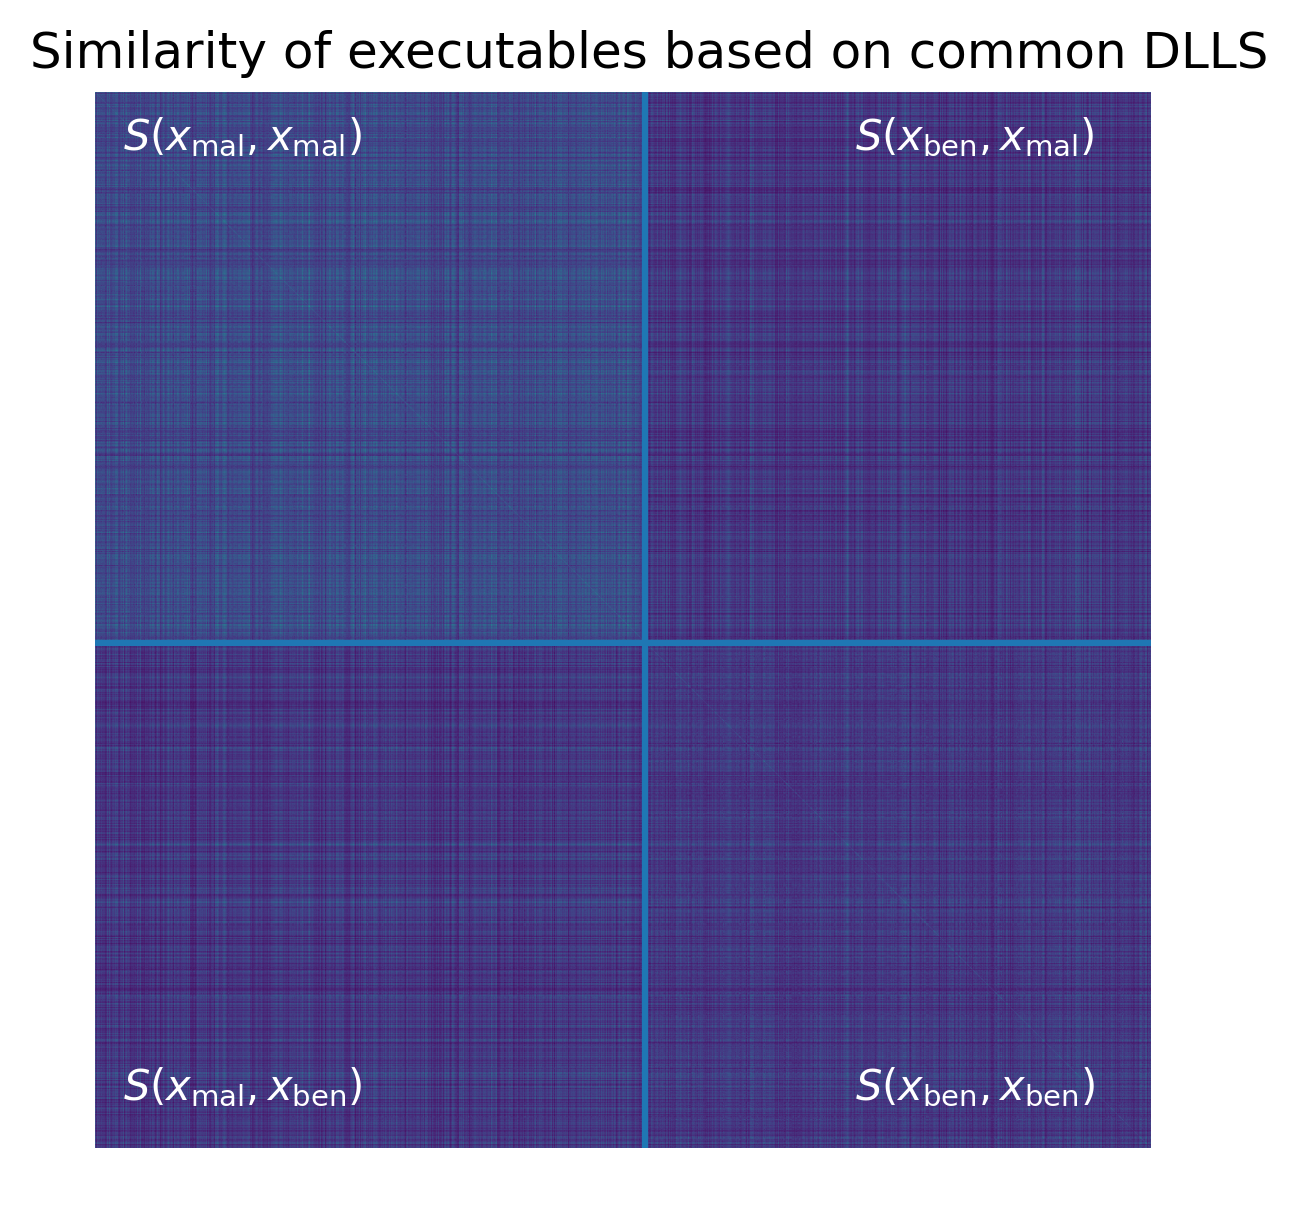

In [87]:
plt.imshow(dll_sim)
plt.axis("off")
plt.title("Similarity of executables based on common DLLS")
plt.hlines(np.count_nonzero(labels), 0, len(dataset))
plt.vlines(np.count_nonzero(labels), 0, len(dataset))
plt.text(300, 600, r"$S(x_\text{mal}, x_\text{mal})$", c="white")
plt.text(300, 10600, r"$S(x_\text{mal}, x_\text{ben})$", c="white")
plt.text(8000, 10600, r"$S(x_\text{ben}, x_\text{ben})$", c="white")
plt.text(8000, 600, r"$S(x_\text{ben}, x_\text{mal})$", c="white")
plt.show()

In [88]:
most_similar = find_most_similar(dll_sim)
sim = dll_sim[most_similar[:, 0], most_similar[:, 1]]

df = pd.DataFrame(
    {
        ("Similarity", ""): sim,
        ("Programs", "1"): programs[most_similar[:, 0]],
        ("Programs", "2"): programs[most_similar[:, 1]],
    }
)
df.columns = pd.MultiIndex.from_tuples(df.columns)
df

Similarity                                     Programs  \
                                                        1   
0        1.0             x86_64-w64-mingw32-inflatehd.exe   
1        1.0  VirusShare_4970c045905c21a7aa69037f0e1d06a0   
2        1.0  VirusShare_425122817931a17ffe51d2dd9c16d1e0   
3        1.0  VirusShare_3bdfd0a1dac4ca0528618d3ce2891190   
4        1.0  VirusShare_54f69117b4356757bebd39f160440e50   
5        1.0  VirusShare_496c8360955d879da3f5dd7b46bb2952   
6        1.0  VirusShare_5745b70c19b0a38c2287a9107026d080   
7        1.0  VirusShare_565d706b74250b5f1a657e362c036e30   
8        1.0  VirusShare_3d6d2849f4e17c1902ecafaa480abee0   
9        1.0  VirusShare_496c8360955d879da3f5dd7b46bb2952   

                                                
                                             2  
0                              llvm-config.exe  
1  VirusShare_1f6d916c081c16803da542a9ba280459  
2  VirusShare_07e774bf1599ff4124848ec4c4907736  
3  VirusShare_577964e6b790e544421743591f903b90  
4  VirusShare_5b39ec65b59cd623aa17c13c388a8f60  
5  VirusShare_4b20242f14cb0c10c830d1078ba25500  
6  VirusShare_48c52201f33d6213a1985b59af50a300  
7  VirusShare_2bb0065b143c2b0e746e3ec84fbca798  
8  VirusShare_2bb51a66153b0b3e3b8170a8db8fdbc5  
9  VirusShare_54f69117b4356757bebd39f160440e50

In [89]:
print(
    f"Average similarity of malicious samples: {np.mean(dll_sim[:n_mal, :n_mal]):.4f}"
)
print(
    f"Average similarity of malicious and benign samples: {np.mean(dll_sim[n_mal:, :n_mal]):.4f}"
)
print(f"Average similarity of benign samples: {np.mean(dll_sim[n_mal:, n_mal:]):.4f}")

Average similarity of malicious samples: 0.2249

Average similarity of malicious and benign samples: 0.1606

Average similarity of benign samples: 0.1643

## Visualisation 

### PCA

In [90]:
pca = PCA(n_components=2)
X_hat = pca.fit_transform(dll_matrix_processed)

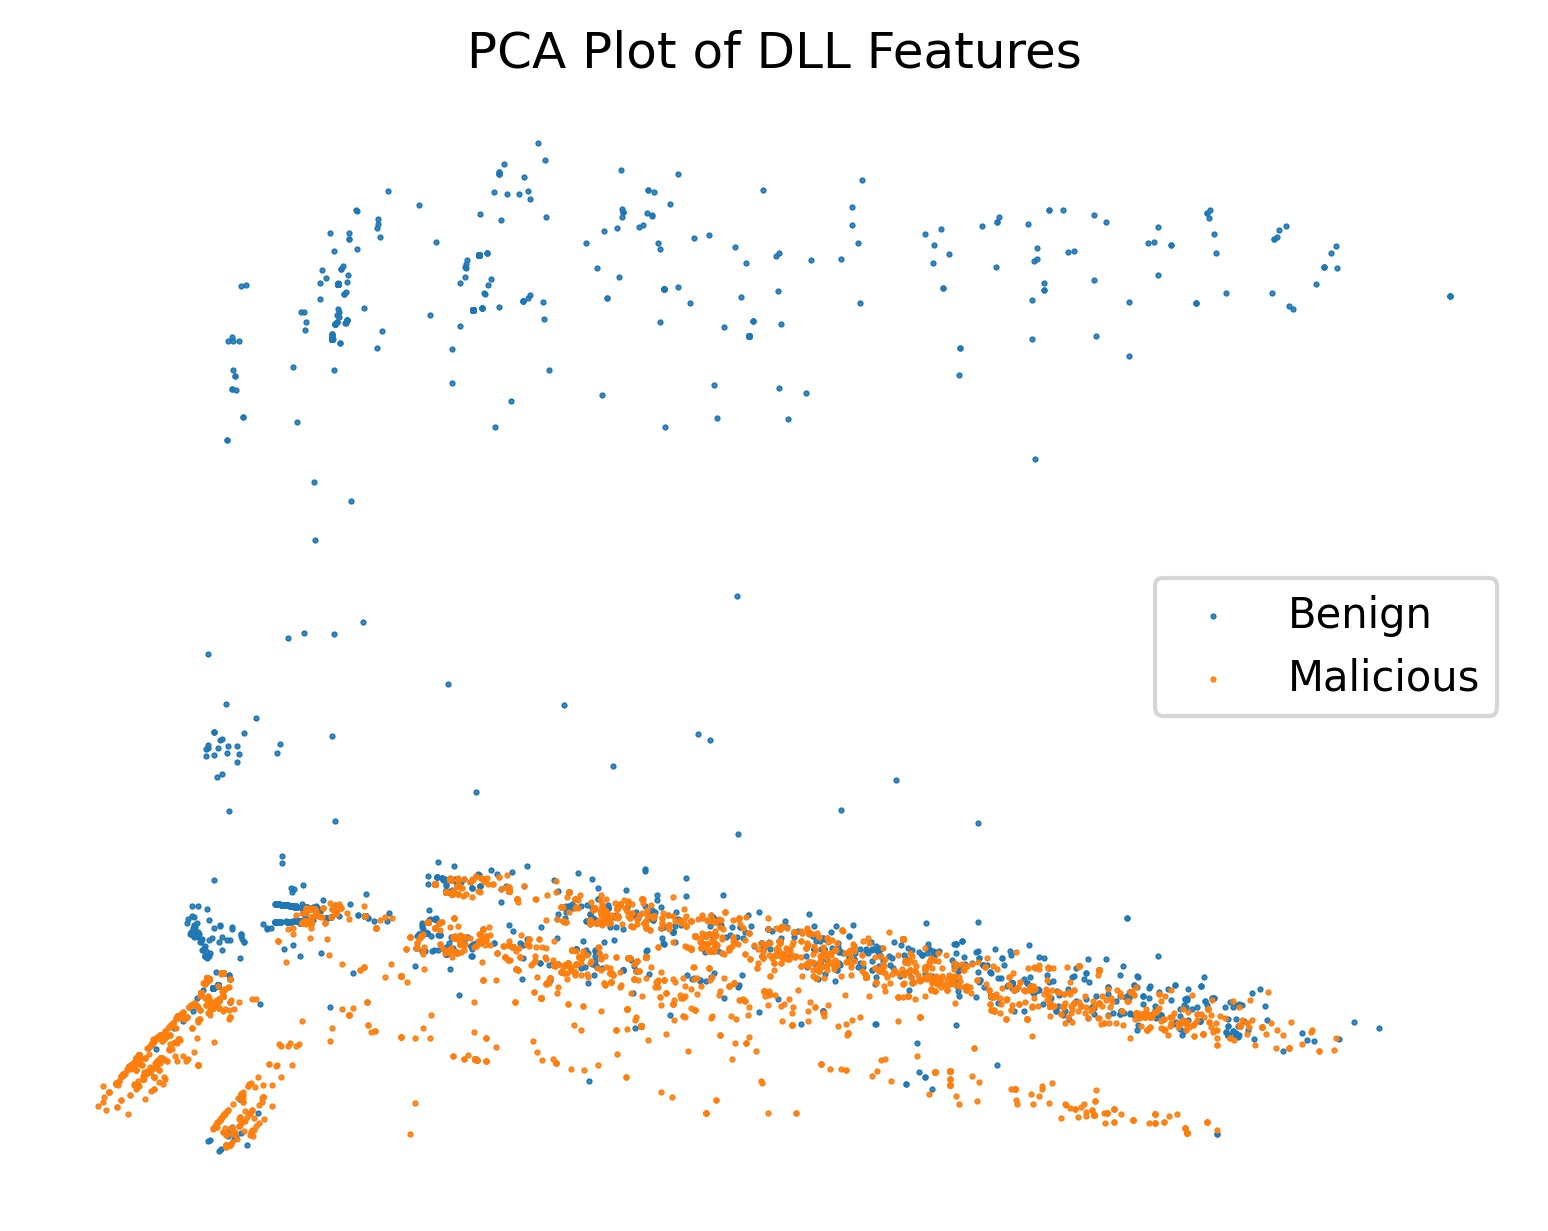

In [91]:
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("PCA Plot of DLL Features")
plt.legend()
plt.show()

### MDS

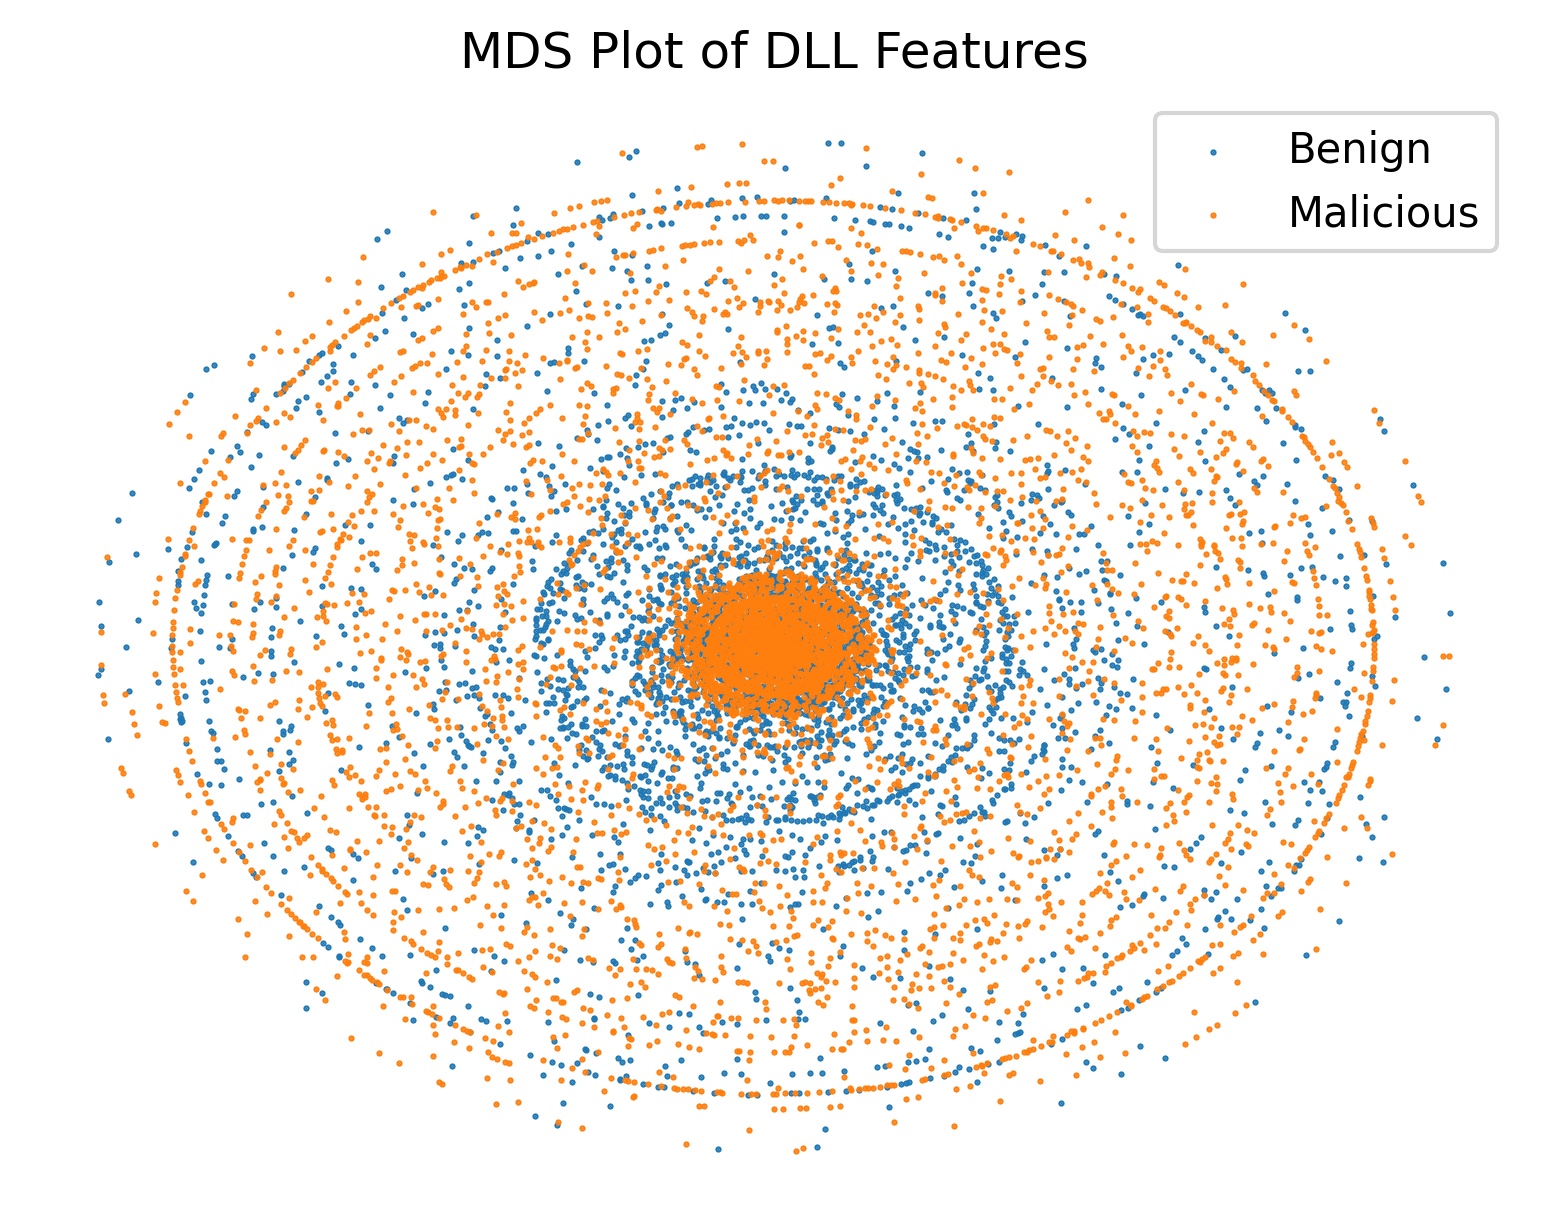

In [ ]:
mds = MDS(dissimilarity="precomputed")
X_hat = mds.fit_transform(dll_sim)
plt.scatter(X_hat[labels == 0, 0], X_hat[labels == 0, 1], label="Benign", s=0.25)
plt.scatter(X_hat[labels == 1, 0], X_hat[labels == 1, 1], label="Malicious", s=0.25)
plt.axis("off")
plt.title("MDS Plot of DLL Features")
plt.legend()
plt.show()

## Characteristics

In [102]:
malicious_dlls = [
    dll for program in dlls["malicious"].keys() for dll in dlls["malicious"][program]
]
malicious_dlls_usage = Counter(malicious_dlls)

benign_dlls = [
    dll for program in dlls["benign"].keys() for dll in dlls["benign"][program]
]
benign_dlls_usage = Counter(benign_dlls)

### Malicious DLLs

In [104]:
only_mal = set(malicious_dlls) - set(benign_dlls)
print(f"{len(only_mal)} DLLs only seen in malicious binaries")
malicious_usage = {dll: malicious_dlls_usage[dll] for dll in only_mal}
malicious_usage = dict(
    reversed(sorted(malicious_usage.items(), key=lambda item: item[1]))
)

pd.DataFrame(
    {
        "DLL name": malicious_usage.keys(),
        "Number of occurrences": malicious_usage.values(),
        "Frequency": np.array(list(malicious_usage.values())) / n_mal,
    }
).head(10)

579 DLLs only seen in malicious binaries

,DLL name,Number of occurrences,Frequency
0,MSVBVM60.DLL,457,0.078902
1,AIMP2.dll,97,0.016747
2,MSVCP60.dll,58,0.010014
3,iMap.bpl,48,0.008287
4,URLMON.DLL,44,0.007597
5,ntoskrnl.exe,35,0.006043
6,MFC42u.DLL,29,0.005007
7,WININET.DLL,29,0.005007
8,rtl100.bpl,28,0.004834
9,rtl70.bpl,25,0.004316


### Benign DLLs

In [96]:
only_ben = set(benign_dlls) - set(malicious_dlls)
print(f"{len(only_ben)} DLLs only seen in benign binaries")
benign_usage = {dll: benign_dlls_usage[dll] for dll in only_ben}
benign_usage = dict(reversed(sorted(benign_usage.items(), key=lambda item: item[1])))

pd.DataFrame(
    {
        "DLL name": benign_usage.keys(),
        "Number of occurrences": benign_usage.values(),
        "Frequency": np.array(list(benign_usage.values())) / n_ben,
    }
).head(10)

1031 DLLs only seen in benign binaries

,DLL name,Number of occurrences,Frequency
0,api-ms-win-crt-runtime-l1-1-0.dll,750,0.140898
1,api-ms-win-crt-locale-l1-1-0.dll,718,0.134886
2,api-ms-win-crt-math-l1-1-0.dll,711,0.133571
3,api-ms-win-crt-heap-l1-1-0.dll,711,0.133571
4,api-ms-win-crt-stdio-l1-1-0.dll,709,0.133196
5,msys-2.0.dll,656,0.123239
6,VCRUNTIME140.dll,633,0.118918
7,api-ms-win-crt-string-l1-1-0.dll,424,0.079654
8,msys-intl-8.dll,403,0.075709
9,api-ms-win-core-profile-l1-1-0.dll,201,0.037761


### Overall

In [97]:
both = set(benign_dlls) & set(malicious_dlls)
print(f"{len(both)} DLLs seen in both classes across dataset")
sorted_usage = dict(
    {
        k: v
        for k, v in reversed(sorted(dll_usage.items(), key=lambda item: item[1]))
        if k in both
    }
)
m_dlls = [mal_dll for mal_dll in malicious_dlls if mal_dll in both]
b_dlls = [ben_dll for ben_dll in benign_dlls if ben_dll in both]

m_dll_usage = {k: v for k, v in malicious_dlls_usage.items() if k in m_dlls}
b_dll_usage = {k: v for k, v in benign_dlls_usage.items() if k in b_dlls}

m_dll_usage = dict(
    reversed(sorted(m_dll_usage.items(), key=lambda item: sorted_usage[item[0]]))
)
b_dll_usage = dict(
    reversed(sorted(b_dll_usage.items(), key=lambda item: sorted_usage[item[0]]))
)

196 DLLs seen in both classes across dataset

In [98]:
df = pd.DataFrame(
    {
        ("DLL name", ""): sorted_usage.keys(),
        ("Occurrences", "Total"): sorted_usage.values(),
        ("Occurrences", "Malicious"): m_dll_usage.values(),
        ("Occurrences", "Benign"): b_dll_usage.values(),
        ("Frequency", "Overall"): np.array(list(sorted_usage.values())) / len(dataset),
        ("Frequency", "Malicious"): np.array(list(m_dll_usage.values())) / n_mal,
        ("Frequency", "Benign"): np.array(list(b_dll_usage.values())) / n_ben,
    }
)

df.columns = pd.MultiIndex.from_tuples(df.columns)
df.head(n=10)

DLL name Occurrences                  Frequency                    
                      Total Malicious Benign   Overall Malicious    Benign
0  KERNEL32.dll        7360      3649   3711  0.662168  0.630007  0.697163
1    USER32.dll        3966      2712   1254  0.356815  0.468232  0.235581
2  ADVAPI32.dll        3831      2364   1467  0.344669  0.408149  0.275596
3   SHELL32.dll        2376      1468    908  0.213765  0.253453  0.170580
4     ole32.dll        2343      1577    766  0.210796  0.272272  0.143904
5    msvcrt.dll        2193       739   1454  0.197301  0.127590  0.273154
6     GDI32.dll        1873      1282    591  0.168511  0.221340  0.111028
7  OLEAUT32.dll        1480      1031    449  0.133153  0.178004  0.084351
8  kernel32.dll        1367      1217    150  0.122987  0.210117  0.028180
9   VERSION.dll        1146       899    247  0.103104  0.155214  0.046402